In [2]:
%pip install -r requirements.txt

  Using cached nbformat-5.10.4-py3-none-any.whl.metadata (3.6 kB)
  Using cached imageio-2.37.2-py3-none-any.whl.metadata (9.7 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached fastjsonschema-2.21.2-py3-none-any.whl.metadata (2.3 kB)
  Using cached jsonschema-4.26.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached attrs-25.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached referencing-0.37.0-py3-none-any.whl.metadata (2.8 kB)
   ---------------------------------------- 0.0/12.4 MB ? eta -:--:--
   ---------------- ----------------------- 5.2/12.4 MB 25.6 MB/s eta 0:00:01
   ---------------------------------------- 12.4/12.4 MB 30.4 MB/s  0:00:00
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 8.3/8.3 MB 52.4 MB/s  0:00:00
   -------------

## Proyección pinhole

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def proyectar_pinhole(puntos_3d, f):
    """
    Proyección perspectiva básica del modelo pinhole.

    puntos_3d: array (N,3)
    f: distancia focal
    """
    X = puntos_3d[:, 0]
    Y = puntos_3d[:, 1]
    Z = puntos_3d[:, 2]

    x = f * (X / Z)
    y = f * (Y / Z)

    return np.vstack((x, y)).T

## Creación de cubo

In [5]:
def crear_cubo(tamano=1, centro=(0,0,5)):
    cx, cy, cz = centro
    t = tamano / 2

    vertices = np.array([
        [cx-t, cy-t, cz-t],
        [cx+t, cy-t, cz-t],
        [cx+t, cy+t, cz-t],
        [cx-t, cy+t, cz-t],
        [cx-t, cy-t, cz+t],
        [cx+t, cy-t, cz+t],
        [cx+t, cy+t, cz+t],
        [cx-t, cy+t, cz+t],
    ])
    return vertices

## Dibujo de cubo

In [13]:
def dibujar_cubo_2d(puntos_2d, titulo="Proyección", limite=3):
    aristas = [
        (0,1),(1,2),(2,3),(3,0),
        (4,5),(5,6),(6,7),(7,4),
        (0,4),(1,5),(2,6),(3,7)
    ]

    fig, ax = plt.subplots(figsize=(6,6))

    for a in aristas:
        p1 = puntos_2d[a[0]]
        p2 = puntos_2d[a[1]]
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]])

    ax.scatter(puntos_2d[:,0], puntos_2d[:,1])

    ax.set_aspect('equal', adjustable='box')

    # Fijar límites manualmente
    ax.set_xlim(-limite, limite)
    ax.set_ylim(-limite, limite)

    ax.set_xlabel("x'")
    ax.set_ylabel("y'")
    ax.set_title(titulo)
    ax.invert_yaxis()
    ax.grid(True)

    plt.show()

## Efecto
Se realiza  proyección con dos distancias focales distintas

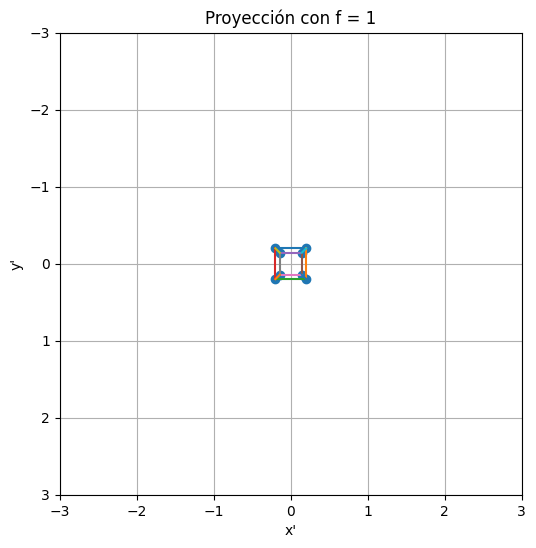

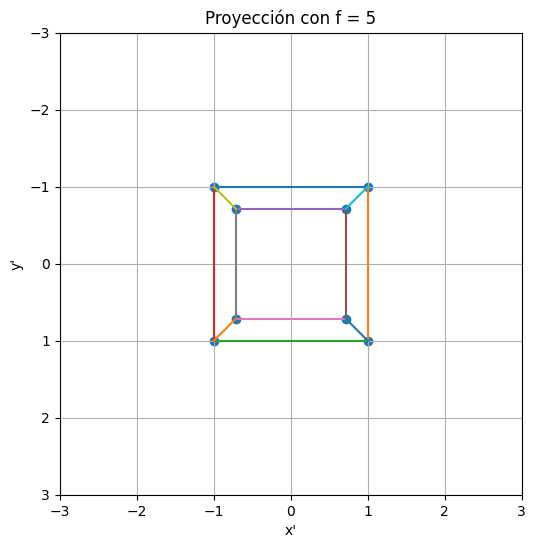

In [14]:
# Crear cubo
cubo = crear_cubo(tamano=2, centro=(0,0,6))

# Focal pequeña
f1 = 1
proy1 = proyectar_pinhole(cubo, f1)
dibujar_cubo_2d(proy1, f"Proyección con f = {f1}")

# Focal grande
f2 = 5
proy2 = proyectar_pinhole(cubo, f2)
dibujar_cubo_2d(proy2, f"Proyección con f = {f2}")

## Parámetros intrínsecos
```
[fx  0  cx]
[0  fy  cy]
[0   0   1]
```

In [16]:
def proyectar_con_K(puntos_3d, K):
    """
    Proyección usando matriz intrínseca K.
    puntos_3d: (N,3)
    K: matriz intrínseca 3x3
    """
    puntos_3d = puntos_3d.T  # (3,N)

    # Coordenadas normalizadas
    puntos_norm = puntos_3d / puntos_3d[2, :]

    # Aplicar matriz intrínseca
    puntos_img = K @ puntos_norm

    return puntos_img[:2, :].T

In [17]:
ancho = 800
alto = 600

fx = 800
fy = 800
cx = ancho / 2
cy = alto / 2

K = np.array([
    [fx, 0, cx],
    [0, fy, cy],
    [0, 0, 1]
])

In [18]:
cubo = crear_cubo(tamano=2, centro=(0,0,6))
proy = proyectar_con_K(cubo, K)

In [19]:
def dibujar_imagen(puntos_2d, ancho, alto, titulo="Proyección con K"):
    aristas = [
        (0,1),(1,2),(2,3),(3,0),
        (4,5),(5,6),(6,7),(7,4),
        (0,4),(1,5),(2,6),(3,7)
    ]

    fig, ax = plt.subplots(figsize=(8,6))

    for a in aristas:
        p1 = puntos_2d[a[0]]
        p2 = puntos_2d[a[1]]
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]])

    ax.scatter(puntos_2d[:,0], puntos_2d[:,1])

    ax.set_xlim(0, ancho)
    ax.set_ylim(alto, 0)  # invertir eje Y como imagen
    ax.set_title(titulo)
    ax.set_aspect('equal')
    ax.grid(True)

    plt.show()

### fx y fy grande

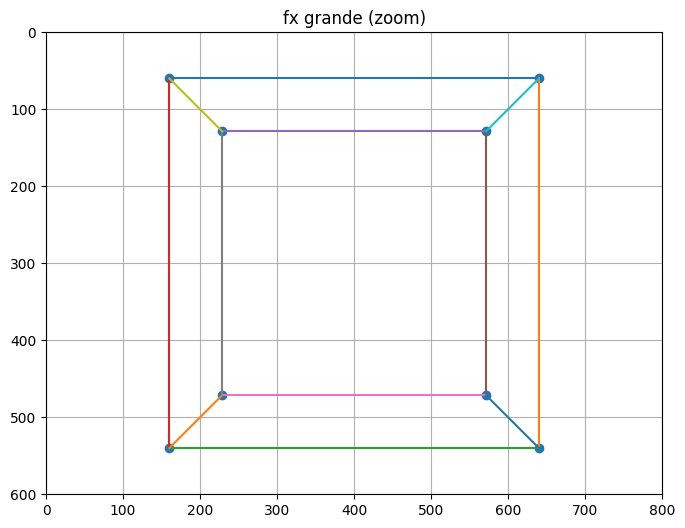

In [20]:
fx = 1200
fy = 1200
K_zoom = np.array([
    [fx, 0, cx],
    [0, fy, cy],
    [0, 0, 1]
])

proy_zoom = proyectar_con_K(cubo, K_zoom)
dibujar_imagen(proy_zoom, ancho, alto, "fx grande (zoom)")

### fx!=fy

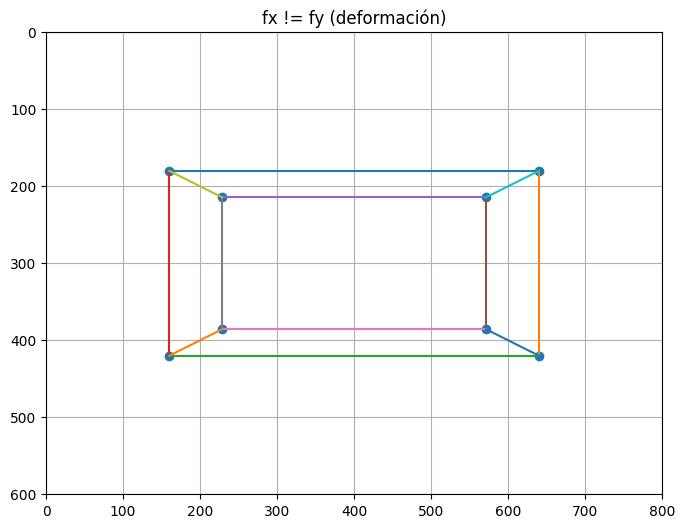

In [21]:
fx = 1200
fy = 600

K_dist = np.array([
    [fx, 0, cx],
    [0, fy, cy],
    [0, 0, 1]
])

proy_dist = proyectar_con_K(cubo, K_dist)
dibujar_imagen(proy_dist, ancho, alto, "fx != fy (deformación)")

### Cambiar centro óptico

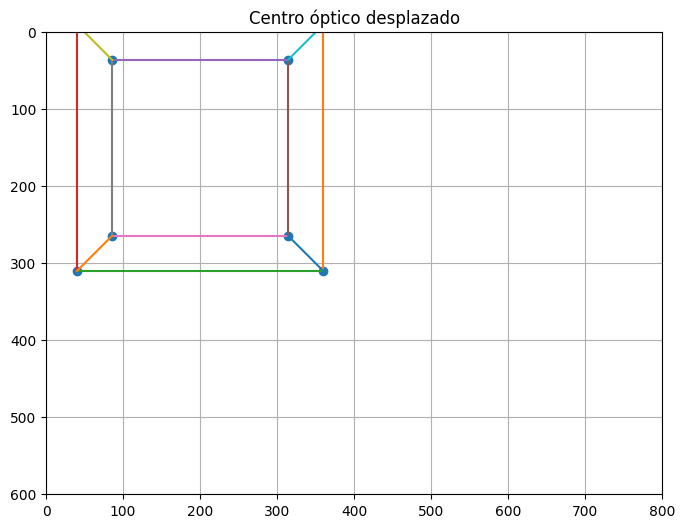

In [22]:
cx = 200
cy = 150

K_shift = np.array([
    [800, 0, cx],
    [0, 800, cy],
    [0, 0, 1]
])

proy_shift = proyectar_con_K(cubo, K_shift)
dibujar_imagen(proy_shift, ancho, alto, "Centro óptico desplazado")

## Parámetros extrínsecos

In [23]:
def transformar_extrinsecos(puntos_3d, R, t):
    """
    Aplica transformación mundo → cámara.
    
    puntos_3d: (N,3)
    R: (3,3)
    t: (3,1)
    """
    return (R @ puntos_3d.T + t).T

### Rotación en y

In [24]:
def rotacion_y(theta):
    return np.array([
        [np.cos(theta), 0, np.sin(theta)],
        [0, 1, 0],
        [-np.sin(theta), 0, np.cos(theta)]
    ])

### Pipeline completo

In [25]:
def proyectar_completo(puntos_3d, K, R, t):
    # Mundo → Cámara
    puntos_cam = transformar_extrinsecos(puntos_3d, R, t)
    
    # Proyección con intrínsecos
    puntos_img = proyectar_con_K(puntos_cam, K)
    
    return puntos_img

### Simular movimiento de cámara

#### Rotación de cámara

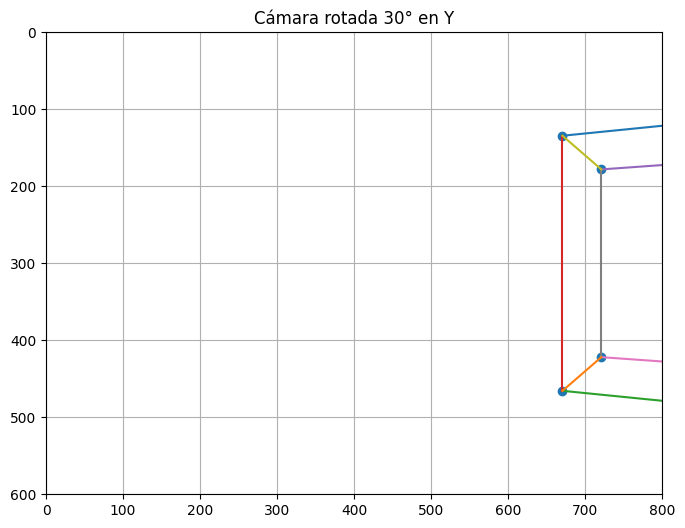

In [26]:
theta = np.radians(30)
R = rotacion_y(theta)
t = np.array([[0], [0], [0]])

proy_rot = proyectar_completo(cubo, K, R, t)
dibujar_imagen(proy_rot, ancho, alto, "Cámara rotada 30° en Y")

### Traslación de cámara

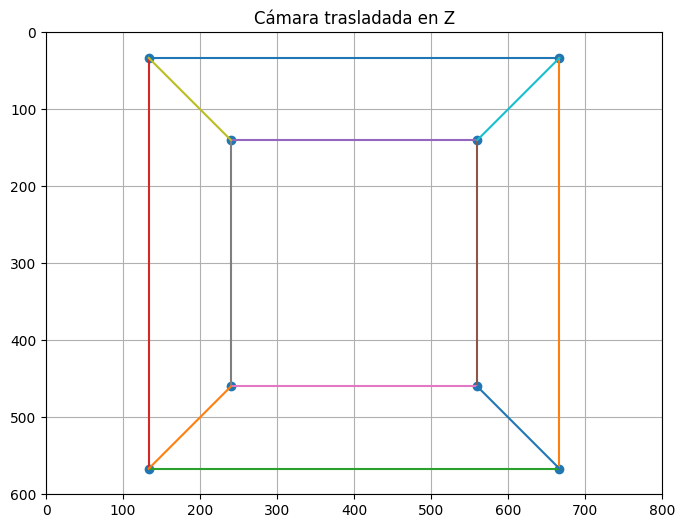

In [27]:
R = np.eye(3)
t = np.array([[0], [0], [-2]])  # cámara avanza

proy_trans = proyectar_completo(cubo, K, R, t)
dibujar_imagen(proy_trans, ancho, alto, "Cámara trasladada en Z")

## Calibración de cámara con patrón